In [46]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

os.makedirs('../../output/tables', exist_ok=True)
os.makedirs('../../output/figs', exist_ok=True)

In [47]:
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 9,
    'axes.titlesize'   : 10,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'legend.fontsize'  : 8,
    'figure.dpi'       : 150, # High resolution for paper quality
})

Load Data

In [48]:
df = pd.read_csv('../../output/processed_data/05_filtered.csv')

Calculate AR and daily spread

In [49]:
# AR was computed and sanity-checked in NB05.
# It is loaded directly from 05_filtered.csv — no need to recompute here.
assert 'AR' in df.columns, \
    "AR column missing from 05_filtered.csv — re-run NB05 first."
print(f'✓ AR loaded from 05_filtered.csv  ({df["AR"].notna().sum()} non-null values)')

# Spread is not in the saved CSV — compute it fresh here (high - low)
df['Spread'] = df['high'] - df['low']

✓ AR loaded from 05_filtered.csv  (69390 non-null values)


Wilcoxon Signed Rank test

In [50]:
full_window = df[(df['day'] >= -5) & (df['day'] <= 30)]
stock_cars = full_window.groupby(['symbol', 'sector'])['AR'].sum().reset_index()
stock_cars.rename(columns={'AR':'CAR'}, inplace = True)
stock_cars['CAR(%)'] = stock_cars['CAR'] * 100

wilcoxon_results = []
sectors = stock_cars['sector'].unique()

for sector in sectors:
    sector_data = stock_cars[stock_cars['sector'] == sector]['CAR(%)']
    n_stocks = len(sector_data)

    if n_stocks > 1:
        try:
            w_stat, p_val_w  = stats.wilcoxon(sector_data, alternative='two-sided')
        except ValueError:
            w_stat, p_val_w = np.nan, np.nan
    else:
        w_stat, p_val_w = np.nan, np.nan
    
    wilcoxon_results.append({
        'Sector': sector,
        'N': n_stocks,
        'Median CAR(%)': sector_data.median(),
        'W-statistic': w_stat,
        'p-value': p_val_w,
        'Significant': p_val_w < 0.05 if pd.notna(p_val_w) else False
    })

wilcoxon_df = pd.DataFrame(wilcoxon_results).sort_values(by='Median CAR(%)', ascending=False)

wilcoxon_df.to_csv('../../output/tables/wilcoxon_results.csv', index=False)
formatted_df = wilcoxon_df.copy()
formatted_df['Median CAR(%)'] = formatted_df['Median CAR(%)'].apply(lambda x: f"{x:.2f}%")
formatted_df['p-value'] = formatted_df['p-value'].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
formatted_df.to_csv('../../output/tables/wilcoxon_results_formatted.csv', index=False)  


Volatility and Liquidity Analysis

In [51]:
print("Running pre Vs. Post Disaster Volatility & Liquidity Analysis")

pre_window = df[(df['day'] >= -30) & (df['day'] <= -6)]
post_window = df[(df['day'] >= 0) & (df['day'] <= 24)]

pre_market_spread = pre_window.groupby('day')['Spread'].mean().reset_index()
post_market_spread = post_window.groupby('day')['Spread'].mean().reset_index()

pre_market_vol = pre_window.groupby('day')['volume'].mean().reset_index()
post_market_vol = post_window.groupby('day')['volume'].mean().reset_index()


t_stat_spread, p_val_spread = stats.ttest_ind(
    pre_market_spread['Spread'], post_market_spread['Spread'], equal_var=False
)
t_stat_vol, p_val_vol = stats.ttest_ind(
    pre_market_vol['volume'], post_market_vol['volume'], equal_var=False
)

volatility_liquidity_results = pd.DataFrame({
    'Metric': ['Volatility (Mean Spread)', 'Liquidity (Total Volume)'],
    'Pre-Event Mean': [pre_market_spread['Spread'].mean(), pre_market_vol['volume'].mean()],
    'Post-Event Mean': [post_market_spread['Spread'].mean(), post_market_vol['volume'].mean()],
    'T-Statistic': [t_stat_spread, t_stat_vol],
    'P-Value': [p_val_spread, p_val_vol],
    'Significance_at_5%': [p_val_spread < 0.05, p_val_vol < 0.05]
})

volatility_liquidity_results.to_csv('../../output/tables/volatility_liquidity_summary.csv', index=False)


Running pre Vs. Post Disaster Volatility & Liquidity Analysis


Publication Quality Plots

/var/folders/db/4m8dhthn51d8sxyp9mp9sd_00000gn/T/ipykernel_3530/567858985.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CAR(%)', y='sector', data=stock_cars, order=order, palette='coolwarm')


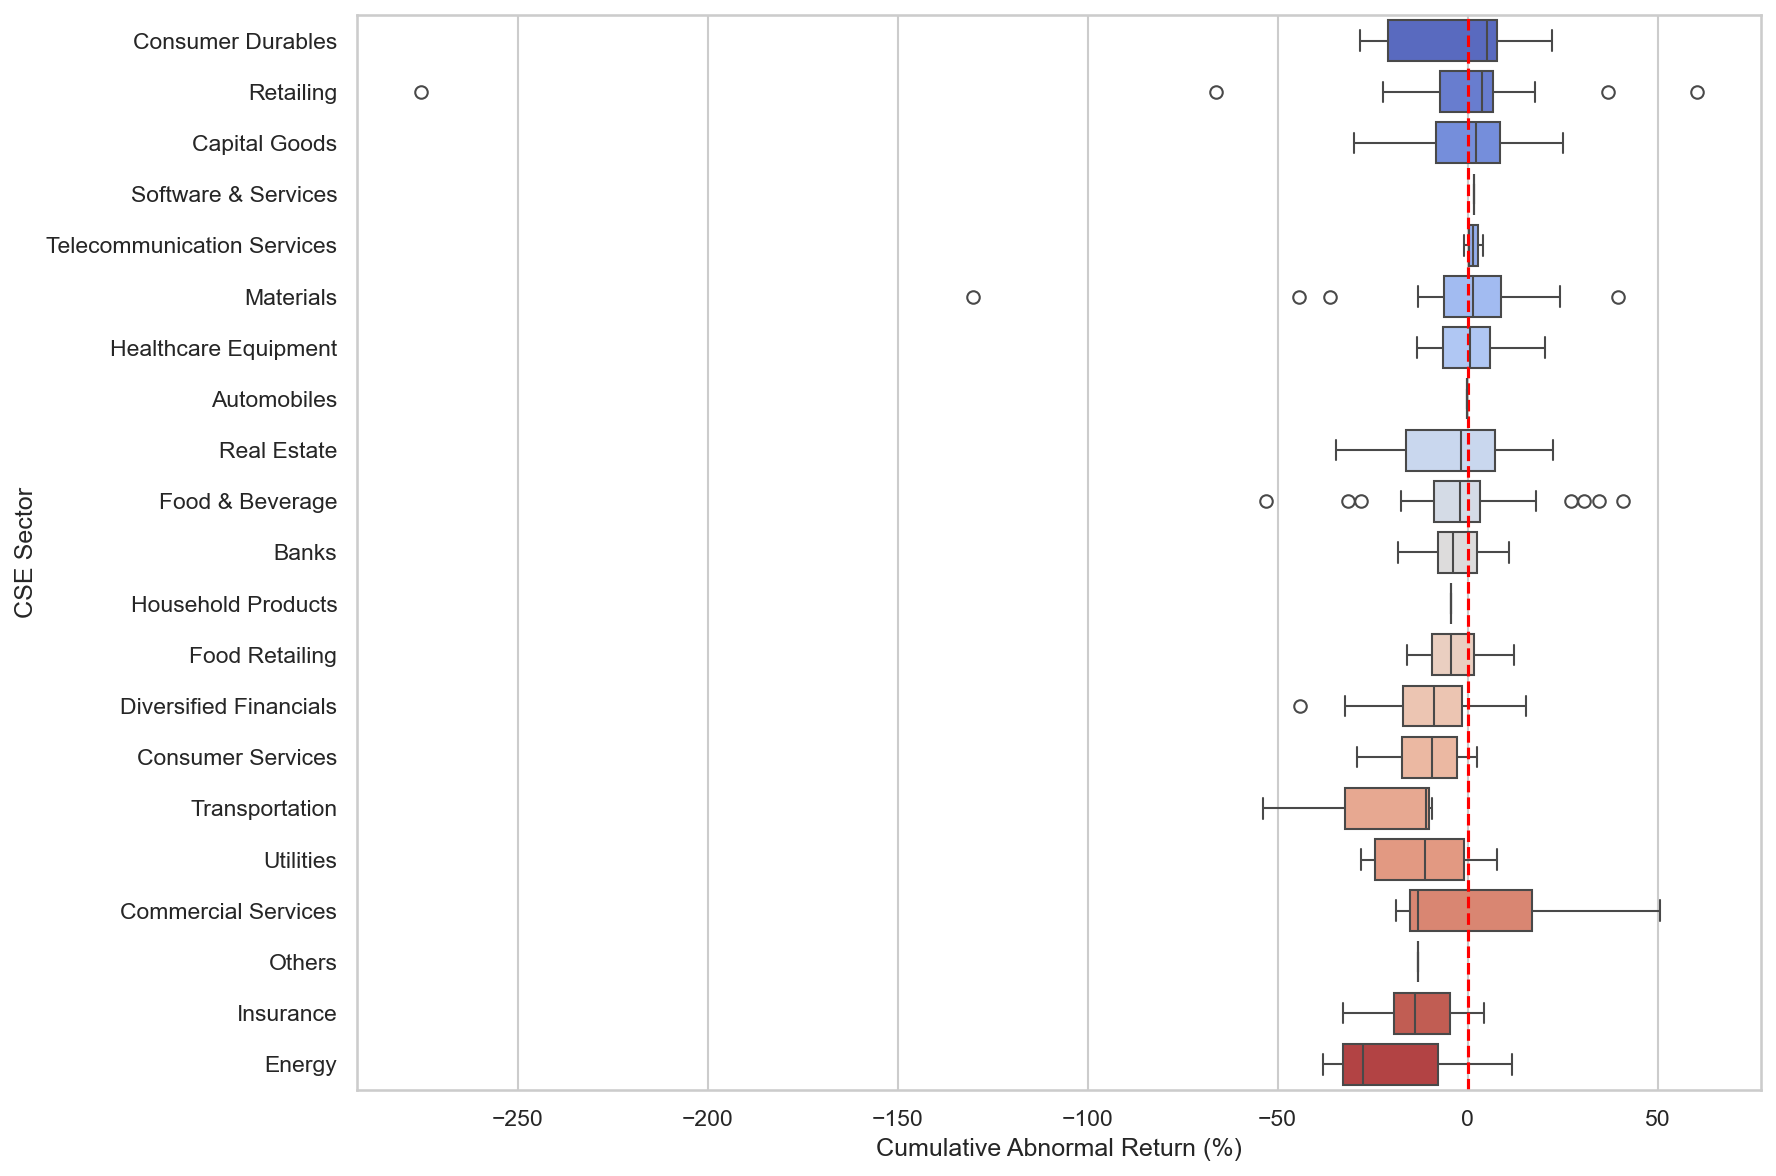

In [52]:
sns.set_theme(style="whitegrid")

#1. Sector Car Plot[-5, +30]
plt.figure(figsize=(12, 8))

order = stock_cars.groupby('sector')['CAR(%)'].median().sort_values(ascending=False).index
sns.boxplot(x='CAR(%)', y='sector', data=stock_cars, order=order, palette='coolwarm')

plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Cumulative Abnormal Return (%)', fontsize=12)
plt.ylabel('CSE Sector', fontsize=12)
plt.tight_layout()
plt.savefig('../../output/figs/sector_car_boxplot.pdf', dpi=300)
plt.show()
plt.close()

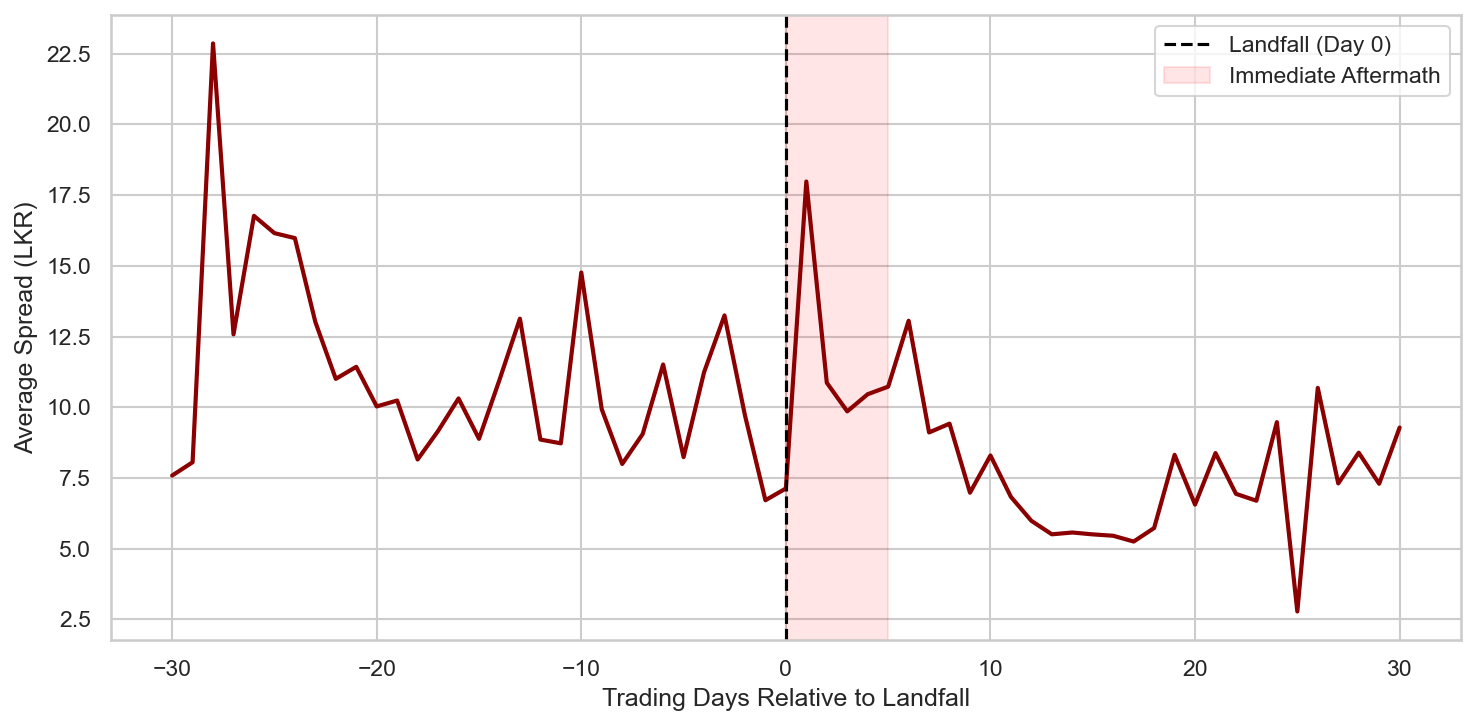

In [53]:
#2. Market Volatility over Time

daily_spread = df[(df['day'] >= -30) & (df['day'] <= 30)].groupby('day')['Spread'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x='day', y='Spread', data=daily_spread, color='darkred', linewidth=2)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Landfall (Day 0)')
plt.axvspan(0, 5, color='red', alpha=0.1, label='Immediate Aftermath')
plt.xlabel('Trading Days Relative to Landfall', fontsize=12)
plt.ylabel('Average Spread (LKR)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../../output/figs/market_volatility_lineplot.pdf', dpi=300)
plt.show()
plt.close()

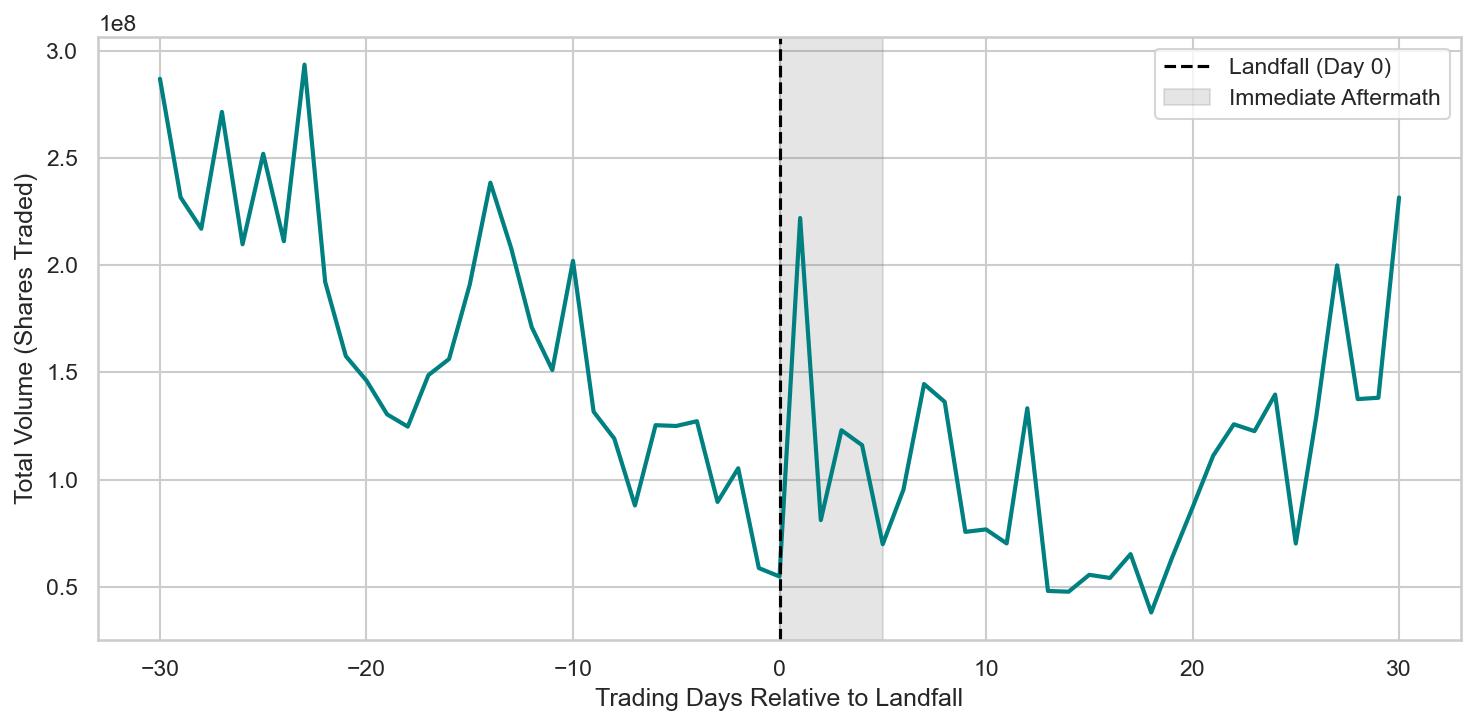

In [54]:
#3. Market Liquidity over Time

daily_vol = df[(df['day'] >= -30) & (df['day'] <= 30)].groupby('day')['volume'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x='day', y='volume', data=daily_vol, color='teal', linewidth=2)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Landfall (Day 0)')
plt.axvspan(0, 5, color='gray', alpha=0.2, label='Immediate Aftermath')
plt.xlabel('Trading Days Relative to Landfall', fontsize=12)
plt.ylabel('Total Volume (Shares Traded)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../../output/figs/market_liquidity_lineplot.pdf', dpi=300)
plt.show()
plt.close()